# Continuation — 40명 도달 이후 관측 활동 비교

## 공통 기준
- 현재 네트워크 스냅샷의 일반 계정(운영·관리 계정 제외)을 사용자 ID로 중복 제거합니다.
- 학교 ID는 현재 스냅샷의 학교입니다. 과거 전학·탈퇴 이력까지 복원한 모집단은 아닙니다.
- D0는 이 모집단의 누적 가입자가 처음 40명에 도달한 날짜입니다. 실제 기능 활성화 로그 시점과 구분합니다.
- 확산 유형은 2023년 4~5월 D0 도달 학교에서 D+1~7, D+8~14 가입자 수의 각각 중앙값으로 분류합니다.
- 최초 가입 후 7·14일과 D0 전후 구간은 서로 다른 시간 기준입니다.
- 유형은 사후 구간으로 분류한 기술 통계입니다. 예측 변수나 인과 효과로 해석하지 않습니다.
- 원본과 동일하게 가입 기록이 없는 학교·일은 0명으로 처리합니다. 추출 범위 밖의 기간을 무가입으로 간주하지 않도록 원본 데이터의 관찰기간을 확인해야 합니다.

## Continuation 해석 범위 — 원본 분석을 재현하는 탐색용 코드
- 원본의 종합 지표와 기능별 지표를 함께 보존했습니다. 질문·투표·포인트는 표본 범위가 제한될 수 있어 전체 학교 이용률로 발표하지 않습니다.
- `ping_current_*`는 현재 상태 지표입니다. 일자 열이 실제 읽기·답변 발생일을 뜻하는지 원천 SQL 확인 전에는 Ping 행동 시점 기반 리텐션으로 확정하지 않습니다.
- 아래 종합 활동량은 서로 다른 기능 건수를 단순 합산한 값입니다. 출석만 사용한 재활동률을 마지막에 별도 계산합니다.
- 기록 없는 학교·기간을 0으로 채우는 원본 계산을 유지했습니다. 이는 **관측 기록 0**이며 수집 누락과 실제 무활동을 구별하지 못합니다.
- 기능별 1건 이상 관찰 학교 비율은 데이터 수집 범위를 입증하는 커버리지 지표가 아닙니다.
- 활동량 비율(D8~14 총량 / D1~7 총량)과 같은 사용자의 재활동률은 다른 지표입니다.
- 현재 학교 소속을 과거 활동에 연결하며, 모든 학교의 14일 관찰이 완료되었는지는 별도 검증해야 합니다.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from IPython.display import display

# 기본 구조: 같은 상위 폴더 아래 team7/ 와 team7_marts/
# 다른 위치면 이 한 줄에 실제 폴더 경로를 입력합니다.
DATA_DIR_OVERRIDE = os.environ.get("TEAM7_MARTS_DIR", "")
if DATA_DIR_OVERRIDE:
    data_dir = Path(DATA_DIR_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = []
    for parent in [current, *current.parents]:
        candidates.extend([parent / "team7_marts", parent.parent / "team7_marts"])
    data_dir = next((p for p in candidates if p.is_dir()), None)
    if data_dir is None:
        raise FileNotFoundError("team7_marts 폴더가 없습니다. DATA_DIR_OVERRIDE에 실제 폴더 경로를 입력하세요.")
if not data_dir.is_dir():
    raise FileNotFoundError(f"데이터 폴더가 없습니다: {data_dir}")
print("데이터 폴더:", data_dir)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if font in fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

def read_mart(filename, required):
    path = data_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f"필요한 마트가 없습니다: {path}")
    frame = pd.read_csv(path, low_memory=False, na_values=[r"\N"])
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise ValueError(f"{filename}: 필수 컬럼 누락 {missing}")
    return frame

network = read_mart("mart_user_network_snapshot.csv", [
    "user_id", "school_id", "user_created_at", "is_staff", "is_superuser"
])
for column in ["is_staff", "is_superuser"]:
    network[column] = pd.to_numeric(network[column], errors="coerce")

데이터 폴더: /Users/jangjunyoung/DA15_Part4/team7_marts


In [2]:
# ============================================================
# 2. 분석용 사용자 데이터 정리
# ============================================================

users = network.copy()

# 관리자·운영 계정 제외
users = users[
    users["is_superuser"].fillna(0).eq(0)
    & users["is_staff"].fillna(0).eq(0)
].copy()

# 자료형 변환
users["school_id"] = pd.to_numeric(
    users["school_id"],
    errors="coerce"
)

users["user_id"] = pd.to_numeric(
    users["user_id"],
    errors="coerce"
)

users["user_created_at"] = pd.to_datetime(
    users["user_created_at"],
    errors="coerce"
)

# 분석 필수값이 없는 행 제외
users = users.dropna(
    subset=["user_id", "school_id", "user_created_at"]
).copy()

users["user_id"] = users["user_id"].astype("int64")
users["school_id"] = users["school_id"].astype("int64")
users["signup_date"] = users["user_created_at"].dt.normalize()
users["signup_month"] = (
    users["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

# 사용자 중복 제거
users = (
    users
    .sort_values("user_created_at")
    .drop_duplicates("user_id", keep="first")
    .reset_index(drop=True)
)

print("분석 사용자 수:", f"{users['user_id'].nunique():,}명")
print("분석 학교 수:", f"{users['school_id'].nunique():,}개")
print(
    "가입일 범위:",
    users["signup_date"].min(),
    "~",
    users["signup_date"].max()
)

display(users.head())

분석 사용자 수: 677,080명
분석 학교 수: 5,551개
가입일 범위: 2023-03-29 00:00:00 ~ 2024-05-09 00:00:00


,mart_built_at,user_id,gender,user_created_at,is_superuser,is_staff,ban_status,group_id,grade,class_num,school_id,school_address,school_type,student_count,current_friend_count_snapshot,network_degree_count,mutual_friend_count,one_way_friend_count,valid_outbound_listing_count,valid_inbound_listing_count,same_school_friend_count,same_grade_friend_count,same_group_friend_count,unknown_school_relation_count,orphan_friend_reference_count,duplicate_friend_reference_count,is_isolated_current_snapshot,is_isolated_valid_network,is_inbound_only_user,reciprocity_rate,same_school_friend_rate,same_group_friend_rate,degree_centrality,sent_request_count,sent_accepted_count,sent_pending_count,sent_rejected_count,received_request_count,received_accepted_count,received_pending_count,received_rejected_count,total_request_activity_count,accepted_request_record_count,pending_request_record_count,rejected_request_record_count,accepted_request_partner_count,has_accepted_request_partner,repeated_accepted_request_count,sent_acceptance_rate,received_acceptance_rate,sent_decision_acceptance_rate,received_decision_acceptance_rate,network_status,request_status,signup_date,signup_month
0,2026-09-02 00:47:38.728474,831962,F,2023-03-29 05:18:56.162368,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,43,31,31,0,31,31,25,2,0,0,12,0,0,0,0,1.00,0.81,0.00,0.00,1,1,0,0,26,0,26,0,27,1,26,0,1,1,0,1.00,0.00,1.00,NaN,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
1,2026-09-02 00:47:38.728474,832151,M,2023-03-29 12:56:34.989468,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,51,50,50,0,50,50,45,35,32,0,1,0,0,0,0,1.00,0.90,0.64,0.00,10,2,8,0,35,6,29,0,45,8,37,0,8,1,0,0.20,0.17,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
2,2026-09-02 00:47:38.728474,832340,F,2023-03-29 12:56:35.020790,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,57,56,56,0,56,56,51,36,32,0,1,0,0,0,0,1.00,0.91,0.57,0.00,26,7,19,0,25,4,21,0,51,11,40,0,11,1,0,0.27,0.16,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
3,2026-09-02 00:47:38.728474,832520,M,2023-03-29 12:56:35.049311,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,18,17,17,0,17,17,12,3,2,0,1,0,0,0,0,1.00,0.71,0.12,0.00,0,0,0,0,14,0,14,0,14,0,14,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03
4,2026-09-02 00:47:38.728474,832614,M,2023-03-29 12:56:35.064406,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,21,20,20,0,20,20,16,6,4,0,1,0,0,0,0,1.00,0.80,0.20,0.00,0,0,0,0,12,0,12,0,12,0,12,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03


## 학교 ID·D0·확산 유형 독립 생성

In [3]:
# ============================================================
# 4. 학교별 40명 도달 여부 및 도달일 계산
# ============================================================

# 학교별 일별 신규 가입자
school_daily_signup = (
    users
    .groupby(["school_id", "signup_date"])["user_id"]
    .nunique()
    .rename("일별가입자수")
    .reset_index()
    .sort_values(["school_id", "signup_date"])
)

# 학교별 누적 가입자
school_daily_signup["누적가입자수"] = (
    school_daily_signup
    .groupby("school_id")["일별가입자수"]
    .cumsum()
)

# 학교별 최초 가입일
school_first_signup = (
    school_daily_signup
    .groupby("school_id")["signup_date"]
    .min()
    .rename("최초가입일")
    .reset_index()
)

# 학교별 40명 최초 도달일
school_reach_40 = (
    school_daily_signup[
        school_daily_signup["누적가입자수"] >= 40
    ]
    .groupby("school_id")["signup_date"]
    .min()
    .rename("40명_도달일")
    .reset_index()
)

# 학교별 최종 가입자 수
school_final_users = (
    users
    .groupby("school_id")["user_id"]
    .nunique()
    .rename("최종가입자수")
    .reset_index()
)

# 학교 단위 데이터 결합
school_activation = (
    school_first_signup
    .merge(
        school_reach_40,
        on="school_id",
        how="left"
    )
    .merge(
        school_final_users,
        on="school_id",
        how="left"
    )
)

school_activation["40명_도달여부"] = np.where(
    school_activation["40명_도달일"].notna(),
    "40명 도달",
    "40명 미도달"
)

school_activation["40명_도달소요일"] = (
    school_activation["40명_도달일"]
    - school_activation["최초가입일"]
).dt.days + 1

print("전체 학교 수:", f"{school_activation['school_id'].nunique():,}개")

display(
    school_activation["40명_도달여부"]
    .value_counts()
    .rename_axis("도달구분")
    .reset_index(name="학교수")
)

display(school_activation.head())

전체 학교 수: 5,551개


,도달구분,학교수
0,40명 도달,3897
1,40명 미도달,1654


,school_id,최초가입일,40명_도달일,최종가입자수,40명_도달여부,40명_도달소요일
0,1,2023-03-29,2023-04-29,93,40명 도달,32.00
1,4,2023-05-08,2023-05-12,235,40명 도달,5.00
2,5,2023-05-07,2023-05-13,160,40명 도달,7.00
3,6,2023-05-01,2023-05-12,197,40명 도달,12.00
4,7,2023-04-23,2023-05-13,114,40명 도달,21.00


In [4]:
# ============================================================
# 6. 40명 도달일(D0) 기준 상대 일자 생성
# ============================================================

# 2023년 4~5월에 40명에 도달한 학교만 선택
viral_reached_schools = school_activation[
    school_activation["40명_도달일"].between(
        pd.Timestamp("2023-04-01"),
        pd.Timestamp("2023-05-31")
    )
][
    ["school_id", "40명_도달일"]
].copy()

print(
    "4~5월 40명 도달 학교:",
    f"{viral_reached_schools['school_id'].nunique():,}개"
)

# 학교별 일별 가입 데이터에 D0 결합
event_signup = school_daily_signup.merge(
    viral_reached_schools,
    on="school_id",
    how="inner"
)

# D0 기준 상대 일자
event_signup["relative_day"] = (
    event_signup["signup_date"]
    - event_signup["40명_도달일"]
).dt.days

# D-14부터 D+14까지만 사용
event_signup = event_signup[
    event_signup["relative_day"].between(-14, 14)
].copy()

display(event_signup.head())

4~5월 40명 도달 학교: 3,796개


,school_id,signup_date,일별가입자수,누적가입자수,40명_도달일,relative_day
3,1,2023-04-15,3,18,2023-04-29,-14
4,1,2023-04-17,2,20,2023-04-29,-12
5,1,2023-04-19,2,22,2023-04-29,-10
6,1,2023-04-20,1,23,2023-04-29,-9
7,1,2023-04-21,1,24,2023-04-29,-8


In [5]:
# ============================================================
# 6-1. 학교별 D-14~D+14 날짜 균형 맞추기
# ============================================================

school_ids = viral_reached_schools["school_id"].unique()
relative_days = np.arange(-14, 15)

# 모든 학교 × 29일 조합 생성
balanced_school_day = pd.MultiIndex.from_product(
    [school_ids, relative_days],
    names=["school_id", "relative_day"]
).to_frame(index=False)

# 실제 가입자 수 결합
balanced_school_day = balanced_school_day.merge(
    event_signup[
        ["school_id", "relative_day", "일별가입자수"]
    ],
    on=["school_id", "relative_day"],
    how="left"
)

# 가입 기록이 없는 날짜는 0명
balanced_school_day["일별가입자수"] = (
    balanced_school_day["일별가입자수"]
    .fillna(0)
)

print(
    "분석 학교 수:",
    f"{balanced_school_day['school_id'].nunique():,}개"
)

print(
    "학교·일 데이터 수:",
    f"{len(balanced_school_day):,}행"
)

display(balanced_school_day.head())

분석 학교 수: 3,796개
학교·일 데이터 수: 110,084행


,school_id,relative_day,일별가입자수
0,1,-14,3.00
1,1,-13,0.00
2,1,-12,2.00
3,1,-11,0.00
4,1,-10,2.00


In [6]:
# ============================================================
# 7. D0를 제외한 네 구간 설정
# ============================================================

def classify_period(relative_day):
    if -14 <= relative_day <= -8:
        return "도달 이전 D-14~-8"

    if -7 <= relative_day <= -1:
        return "도달 직전 D-7~-1"

    if 1 <= relative_day <= 7:
        return "도달 직후 D+1~+7"

    if 8 <= relative_day <= 14:
        return "도달 후기 D+8~+14"

    return np.nan


period_order = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14"
]

# D0 제외
period_data = balanced_school_day[
    balanced_school_day["relative_day"] != 0
].copy()

period_data["기간"] = period_data["relative_day"].apply(
    classify_period
)

period_data["기간"] = pd.Categorical(
    period_data["기간"],
    categories=period_order,
    ordered=True
)

display(period_data.head())

,school_id,relative_day,일별가입자수,기간
0,1,-14,3.00,도달 이전 D-14~-8
1,1,-13,0.00,도달 이전 D-14~-8
2,1,-12,2.00,도달 이전 D-14~-8
3,1,-11,0.00,도달 이전 D-14~-8
4,1,-10,2.00,도달 이전 D-14~-8


In [7]:
# ============================================================
# 7-1. 학교별 네 구간 가입자 집계
# ============================================================

school_period_summary = (
    period_data
    .groupby(
        ["school_id", "기간"],
        observed=True
    )
    .agg(
        구간추가가입자=("일별가입자수", "sum"),
        일평균가입자=("일별가입자수", "mean"),
        가입발생일수=(
            "일별가입자수",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

display(school_period_summary.head(12))

,school_id,기간,구간추가가입자,일평균가입자,가입발생일수
0,1,도달 이전 D-14~-8,9.00,1.29,5
1,1,도달 직전 D-7~-1,14.00,2.00,5
2,1,도달 직후 D+1~+7,7.00,1.00,3
3,1,도달 후기 D+8~+14,7.00,1.00,5
4,4,도달 이전 D-14~-8,0.00,0.00,0
5,4,도달 직전 D-7~-1,15.00,2.14,3
6,4,도달 직후 D+1~+7,169.00,24.14,7
7,4,도달 후기 D+8~+14,4.00,0.57,3
8,5,도달 이전 D-14~-8,0.00,0.00,0
9,5,도달 직전 D-7~-1,19.00,2.71,5


In [8]:
# ============================================================
# 8. 학교별 네 구간 가입자 데이터를 가로 형태로 변환
# ============================================================

school_diffusion = (
    school_period_summary
    .pivot(
        index="school_id",
        columns="기간",
        values="구간추가가입자"
    )
    .reset_index()
)

school_diffusion.columns.name = None

school_diffusion = school_diffusion.rename(
    columns={
        "도달 이전 D-14~-8": "도달이전_D14_D8",
        "도달 직전 D-7~-1": "도달직전_D7_D1",
        "도달 직후 D+1~+7": "첫째주_D1_D7",
        "도달 후기 D+8~+14": "둘째주_D8_D14"
    }
)

period_columns = [
    "도달이전_D14_D8",
    "도달직전_D7_D1",
    "첫째주_D1_D7",
    "둘째주_D8_D14"
]

school_diffusion[period_columns] = (
    school_diffusion[period_columns]
    .fillna(0)
)

# 도달 소요일과 최종 가입자 수 결합
school_diffusion = school_diffusion.merge(
    school_activation[
        [
            "school_id",
            "40명_도달소요일",
            "최종가입자수"
        ]
    ],
    on="school_id",
    how="left"
)

display(school_diffusion.head())

,school_id,도달이전_D14_D8,도달직전_D7_D1,첫째주_D1_D7,둘째주_D8_D14,40명_도달소요일,최종가입자수
0,1,9.00,14.00,7.00,7.00,32.00,93
1,4,0.00,15.00,169.00,4.00,5.00,235
2,5,0.00,19.00,65.00,2.00,7.00,160
3,6,2.00,21.00,132.00,9.00,12.00,197
4,7,1.00,5.00,55.00,4.00,21.00,114


In [9]:
# ============================================================
# 8-1. 네 가지 확산 유형 분류
# ============================================================

# 도달 후 첫째 주와 둘째 주 중앙값
first_week_median = school_diffusion[
    "첫째주_D1_D7"
].median()

second_week_median = school_diffusion[
    "둘째주_D8_D14"
].median()

conditions = [
    # 첫째 주와 둘째 주 모두 기준 이상
    (
        school_diffusion["첫째주_D1_D7"] >= first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] >= second_week_median
    ),

    # 첫째 주는 높지만 둘째 주는 낮음
    (
        school_diffusion["첫째주_D1_D7"] >= first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] < second_week_median
    ),

    # 첫째 주는 낮지만 둘째 주는 높음
    (
        school_diffusion["첫째주_D1_D7"] < first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] >= second_week_median
    )
]

choices = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형"
]

school_diffusion["확산유형"] = np.select(
    conditions,
    choices,
    default="저확산형"
)

print("첫째 주 분류 기준:", first_week_median)
print("둘째 주 분류 기준:", second_week_median)

type_count = (
    school_diffusion["확산유형"]
    .value_counts()
    .rename_axis("확산유형")
    .reset_index(name="학교수")
)

type_count["학교비율(%)"] = (
    type_count["학교수"]
    / type_count["학교수"].sum()
    * 100
).round(2)

display(type_count)

첫째 주 분류 기준: 76.0
둘째 주 분류 기준: 8.0


,확산유형,학교수,학교비율(%)
0,지속 확산형,1382,36.41
1,저확산형,1288,33.93
2,후발 확산형,586,15.44
3,단기 폭발형,540,14.23


In [10]:
school_viral_clean = read_mart("mart_school_viral_daily_v2_clean.csv.gz", [
    "school_id", "activity_date", "current_roster_40th_signup_at",
    "sent_request_created_count", "sent_created_final_accepted_count",
    "sent_request_user_count", "new_nonstaff_account_count_current_roster"
])
school_viral_clean["school_id"] = pd.to_numeric(school_viral_clean["school_id"], errors="coerce")
school_viral_clean["activity_date"] = pd.to_datetime(school_viral_clean["activity_date"], errors="coerce").dt.normalize()
school_viral_clean["current_roster_40th_signup_at"] = pd.to_datetime(
    school_viral_clean["current_roster_40th_signup_at"], errors="coerce").dt.normalize()
school_viral_clean = school_viral_clean.dropna(subset=["school_id", "activity_date"]).copy()
if school_viral_clean.duplicated(["school_id", "activity_date"]).any():
    raise ValueError("Clean 학교 마트에 학교·날짜 중복이 있습니다. 집계 전 확인하세요.")
canonical_school_map = school_diffusion[["school_id", "확산유형"]].merge(
    school_activation[["school_id", "40명_도달일"]], on="school_id", validate="one_to_one"
).rename(columns={"40명_도달일": "D0"})
school_viral_type_clean = school_viral_clean.merge(
    canonical_school_map, on="school_id", how="inner", validate="many_to_one")
d0_check = school_viral_type_clean[["school_id", "D0", "current_roster_40th_signup_at"]].drop_duplicates()
d0_mismatch = d0_check[d0_check["current_roster_40th_signup_at"].notna()
                       & d0_check["D0"].ne(d0_check["current_roster_40th_signup_at"])]
print("D0가 Clean 마트와 다른 학교 수:", d0_mismatch["school_id"].nunique())
if not d0_mismatch.empty:
    display(d0_mismatch.head(20))
print("이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.")
school_viral_type_clean["relative_day"] = (
    school_viral_type_clean["activity_date"] - school_viral_type_clean["D0"]).dt.days
school_viral_type_clean = school_viral_type_clean[
    school_viral_type_clean["relative_day"].between(-14, 14)].copy()
for col in ["sent_request_created_count", "sent_created_final_accepted_count",
            "sent_request_user_count", "new_nonstaff_account_count_current_roster"]:
    school_viral_type_clean[col] = pd.to_numeric(school_viral_type_clean[col], errors="raise")
print("Clean 마트 결합 학교 수:", school_viral_type_clean["school_id"].nunique())

D0가 Clean 마트와 다른 학교 수: 0
이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.
Clean 마트 결합 학교 수: 3795


In [11]:
required_activity = [
    "user_id", "activity_date", "attendance_record_count",
    "db_question_set_created_count", "db_vote_record_created_count",
    "db_ping_received_record_count", "ping_current_read_record_count",
    "ping_current_answered_record_count", "point_earn_event_count", "point_spend_event_count"
]
user_activity = read_mart("mart_user_activity_daily_v2.csv.gz", required_activity)
user_profile = read_mart("mart_user_viral_profile_v2_clean.csv.gz", [
    "user_id", "current_school_id", "is_staff", "is_superuser"
])
print("활동 데이터 행 수:", len(user_activity))
print("프로필 행 수:", len(user_profile))

활동 데이터 행 수: 8224667
프로필 행 수: 677085


In [12]:
# ============================================================
# 15-2. 사용자 활동 + 학교 + D0 + 확산 유형 결합
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. 사용자-학교 연결 테이블 생성
#    관리자 제외 + 학교가 존재하는 사용자만 사용
# ------------------------------------------------------------

user_school_map = user_profile[
    [
        "user_id",
        "current_school_id",
        "is_staff",
        "is_superuser",
    ]
].copy()

for col in ["user_id", "current_school_id", "is_staff", "is_superuser"]:
    user_school_map[col] = pd.to_numeric(
        user_school_map[col],
        errors="coerce"
    )

user_school_map = (
    user_school_map[
        (user_school_map["is_staff"].fillna(0) == 0)
        & (user_school_map["is_superuser"].fillna(0) == 0)
        & user_school_map["current_school_id"].notna()
    ]
    .drop_duplicates(subset="user_id")
    .rename(columns={"current_school_id": "school_id"})
)

user_school_map["user_id"] = user_school_map["user_id"].astype("Int64")
user_school_map["school_id"] = user_school_map["school_id"].astype("Int64")

print("학교 연결 가능 일반 사용자 수:",
      f"{user_school_map['user_id'].nunique():,}명")


# ------------------------------------------------------------
# 2. 학교별 D0와 확산 유형 테이블 생성
# ------------------------------------------------------------

# Network와 동일한 Clean 마트 관측 학교 집합 및 공통 D0
school_d0_map = school_viral_type_clean[["school_id", "D0", "확산유형"]].drop_duplicates("school_id").copy()

school_d0_map["school_id"] = pd.to_numeric(
    school_d0_map["school_id"],
    errors="coerce"
).astype("Int64")

school_d0_map["D0"] = pd.to_datetime(
    school_d0_map["D0"],
    errors="coerce"
).dt.normalize()

print("D0·확산 유형 보유 학교 수:",
      f"{school_d0_map['school_id'].nunique():,}개")


# ------------------------------------------------------------
# 3. 분석할 활동 컬럼 선택
#    실제 데이터에 존재하는 컬럼만 자동 선택
# ------------------------------------------------------------

candidate_activity_columns = [
    "attendance_record_count",
    "friend_request_sent_count",
    "friend_request_received_count",
    "db_question_set_created_count",
    "db_vote_record_created_count",
    "db_ping_received_record_count",
    "ping_current_read_record_count",
    "ping_current_answered_record_count",
    "point_earn_event_count",
    "point_spend_event_count",
    "db_payment_success_count",
    "db_payment_fail_count",
    "user_initiated_activity_proxy_flag",
    "any_record_observed_flag",
    "context_or_system_only_day_flag",
]

selected_activity_columns = [
    col
    for col in candidate_activity_columns
    if col in user_activity.columns
]

print("\n[이번 분석에 사용하는 활동 컬럼]")
for col in selected_activity_columns:
    print("-", col)


# ------------------------------------------------------------
# 4. 사용자 활동 데이터 정리
# ------------------------------------------------------------

activity_clean = user_activity[
    ["user_id", "activity_date"] + selected_activity_columns
].copy()

activity_clean["user_id"] = pd.to_numeric(
    activity_clean["user_id"],
    errors="coerce"
).astype("Int64")

activity_clean["activity_date"] = pd.to_datetime(
    activity_clean["activity_date"],
    errors="coerce"
).dt.normalize()

for col in selected_activity_columns:
    activity_clean[col] = pd.to_numeric(
        activity_clean[col],
        errors="coerce"
    ).fillna(0)


# ------------------------------------------------------------
# 5. 사용자 활동에 학교 정보 연결
# ------------------------------------------------------------

# 결측 사용자 ID를 서로 매칭하지 않습니다.
activity_clean = activity_clean.dropna(subset=["user_id", "activity_date"])
user_school_map = user_school_map.dropna(subset=["user_id", "school_id"])
if activity_clean.duplicated(["user_id", "activity_date"]).any():
    raise ValueError("활동 마트에 사용자·날짜 중복이 있습니다.")
activity_school = activity_clean.merge(
    user_school_map[["user_id", "school_id"]],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

print("\n학교 연결 후 행 수:", f"{len(activity_school):,}")
print("학교 연결 후 사용자 수:",
      f"{activity_school['user_id'].nunique():,}명")
print("학교 연결 후 학교 수:",
      f"{activity_school['school_id'].nunique():,}개")


# ------------------------------------------------------------
# 6. 학교별 D0와 확산 유형 연결
# ------------------------------------------------------------

activity_school_d0 = activity_school.merge(
    school_d0_map,
    on="school_id",
    how="inner",
    validate="many_to_one"
)

activity_school_d0["relative_day"] = (
    activity_school_d0["activity_date"]
    - activity_school_d0["D0"]
).dt.days


# ------------------------------------------------------------
# 7. D-14 ~ D+14만 선택하고 기간 구분
#    D0는 별도 구간으로 표시
# ------------------------------------------------------------

activity_school_d0 = activity_school_d0[
    activity_school_d0["relative_day"].between(-14, 14)
].copy()

conditions = [
    activity_school_d0["relative_day"].between(-14, -8),
    activity_school_d0["relative_day"].between(-7, -1),
    activity_school_d0["relative_day"].eq(0),
    activity_school_d0["relative_day"].between(1, 7),
    activity_school_d0["relative_day"].between(8, 14),
]

period_labels = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "40명 도달일 D0",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14",
]

activity_school_d0["기간"] = np.select(
    conditions,
    period_labels,
    default=None
)

period_order_activity = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "40명 도달일 D0",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14",
]

activity_school_d0["기간"] = pd.Categorical(
    activity_school_d0["기간"],
    categories=period_order_activity,
    ordered=True
)


# ------------------------------------------------------------
# 8. 최종 결합 결과 확인
# ------------------------------------------------------------

print("\n최종 활동 분석 행 수:",
      f"{len(activity_school_d0):,}")

print("최종 활동 분석 사용자 수:",
      f"{activity_school_d0['user_id'].nunique():,}명")

print("최종 활동 분석 학교 수:",
      f"{activity_school_d0['school_id'].nunique():,}개")

print("\n[확산 유형별 학교 수]")

display(
    activity_school_d0[
        ["school_id", "확산유형"]
    ]
    .drop_duplicates()
    ["확산유형"]
    .value_counts()
    .rename_axis("확산유형")
    .reset_index(name="학교수")
)

display(
    activity_school_d0[
        [
            "user_id",
            "school_id",
            "activity_date",
            "D0",
            "relative_day",
            "기간",
            "확산유형",
        ] + selected_activity_columns
    ].head()
)

학교 연결 가능 일반 사용자 수: 677,080명
D0·확산 유형 보유 학교 수: 3,795개

[이번 분석에 사용하는 활동 컬럼]
- attendance_record_count
- friend_request_sent_count
- friend_request_received_count
- db_question_set_created_count
- db_vote_record_created_count
- db_ping_received_record_count
- ping_current_read_record_count
- ping_current_answered_record_count
- point_earn_event_count
- point_spend_event_count
- db_payment_success_count
- db_payment_fail_count
- user_initiated_activity_proxy_flag
- any_record_observed_flag
- context_or_system_only_day_flag

학교 연결 후 행 수: 8,224,662
학교 연결 후 사용자 수: 677,080명
학교 연결 후 학교 수: 5,551개

최종 활동 분석 행 수: 4,704,622
최종 활동 분석 사용자 수: 621,698명
최종 활동 분석 학교 수: 3,795개

[확산 유형별 학교 수]


,확산유형,학교수
0,지속 확산형,1382
1,저확산형,1287
2,후발 확산형,586
3,단기 폭발형,540


,user_id,school_id,activity_date,D0,relative_day,기간,확산유형,attendance_record_count,friend_request_sent_count,friend_request_received_count,db_question_set_created_count,db_vote_record_created_count,db_ping_received_record_count,ping_current_read_record_count,ping_current_answered_record_count,point_earn_event_count,point_spend_event_count,db_payment_success_count,db_payment_fail_count,user_initiated_activity_proxy_flag,any_record_observed_flag,context_or_system_only_day_flag
1,833024,5464,2023-05-03,2023-05-14,-11,도달 이전 D-14~-8,후발 확산형,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2,833024,5464,2023-05-05,2023-05-14,-9,도달 이전 D-14~-8,후발 확산형,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
3,833024,5464,2023-05-08,2023-05-14,-6,도달 직전 D-7~-1,후발 확산형,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
4,833024,5464,2023-05-13,2023-05-14,-1,도달 직전 D-7~-1,후발 확산형,0,0,9,0,0,0,0,0,0,0,0,0,0,1,1
5,833024,5464,2023-05-14,2023-05-14,0,40명 도달일 D0,후발 확산형,0,0,6,0,0,0,0,0,0,0,0,0,0,1,1


In [13]:
# ============================================================
# 15-3. 학교별·기간별 실제 기능 활동 지표 계산
# ============================================================

activity_analysis = activity_school_d0.copy()

# ------------------------------------------------------------
# 1. 기능별 활동량 생성
# ------------------------------------------------------------

# 질문 생성 + 투표 참여
activity_analysis["투표질문활동수"] = (
    activity_analysis["db_question_set_created_count"]
    + activity_analysis["db_vote_record_created_count"]
)

# Ping 읽기 + 답변
activity_analysis["Ping반응수"] = (
    activity_analysis["ping_current_read_record_count"]
    + activity_analysis["ping_current_answered_record_count"]
)

# 포인트 획득 + 사용
activity_analysis["포인트활동수"] = (
    activity_analysis["point_earn_event_count"]
    + activity_analysis["point_spend_event_count"]
)

# 출석 활동
activity_analysis["출석활동수"] = (
    activity_analysis["attendance_record_count"]
)

# 친구 요청은 앞 단계에서 분석했으므로
# 핵심 기능 활동에서는 제외
activity_analysis["핵심기능활동수"] = (
    activity_analysis["투표질문활동수"]
    + activity_analysis["Ping반응수"]
    + activity_analysis["포인트활동수"]
    + activity_analysis["출석활동수"]
)

# 해당 날짜에 한 번이라도 핵심 기능을 사용했는지
activity_analysis["핵심활동여부"] = (
    activity_analysis["핵심기능활동수"] > 0
).astype(int)


# ------------------------------------------------------------
# 2. 학교·확산 유형·기간별 집계
# ------------------------------------------------------------

school_activity_period = (
    activity_analysis
    .groupby(
        ["school_id", "확산유형", "기간"],
        observed=True
    )
    .agg(
        활동사용자수=("user_id", "nunique"),
        핵심활동사용자수=(
            "user_id",
            lambda x: x[
                activity_analysis.loc[x.index, "핵심활동여부"].eq(1)
            ].nunique()
        ),
        투표질문활동수=("투표질문활동수", "sum"),
        Ping반응수=("Ping반응수", "sum"),
        포인트활동수=("포인트활동수", "sum"),
        출석활동수=("출석활동수", "sum"),
        핵심기능활동수=("핵심기능활동수", "sum"),
    )
    .reset_index()
)

# 관찰된 사용자 중 핵심 기능을 사용한 비율
school_activity_period["핵심활동사용자비율(%)"] = np.where(
    school_activity_period["활동사용자수"] > 0,
    (
        school_activity_period["핵심활동사용자수"]
        / school_activity_period["활동사용자수"]
        * 100
    ),
    np.nan
)


# ------------------------------------------------------------
# 3. 확산 유형·기간별 평균 계산
# ------------------------------------------------------------

type_activity_summary = (
    school_activity_period
    .groupby(
        ["확산유형", "기간"],
        observed=True
    )
    .agg(
        학교수=("school_id", "nunique"),
        학교당_평균활동사용자수=("활동사용자수", "mean"),
        학교당_평균핵심활동사용자수=("핵심활동사용자수", "mean"),
        학교당_평균투표질문활동수=("투표질문활동수", "mean"),
        학교당_평균Ping반응수=("Ping반응수", "mean"),
        학교당_평균포인트활동수=("포인트활동수", "mean"),
        학교당_평균출석활동수=("출석활동수", "mean"),
        학교당_평균핵심기능활동수=("핵심기능활동수", "mean"),
        평균핵심활동사용자비율=(
            "핵심활동사용자비율(%)",
            "mean"
        ),
    )
    .reset_index()
)

# 보기 편하게 반올림
numeric_columns = type_activity_summary.select_dtypes(
    include="number"
).columns

type_activity_summary[numeric_columns] = (
    type_activity_summary[numeric_columns].round(2)
)


# ------------------------------------------------------------
# 4. 결과 확인
# ------------------------------------------------------------

print(
    "학교·기간별 결과 행 수:",
    f"{len(school_activity_period):,}"
)

print(
    "유형·기간별 결과 행 수:",
    f"{len(type_activity_summary):,}"
)

display(type_activity_summary)

학교·기간별 결과 행 수: 16,832
유형·기간별 결과 행 수: 20


,확산유형,기간,학교수,학교당_평균활동사용자수,학교당_평균핵심활동사용자수,학교당_평균투표질문활동수,학교당_평균Ping반응수,학교당_평균포인트활동수,학교당_평균출석활동수,학교당_평균핵심기능활동수,평균핵심활동사용자비율
0,단기 폭발형,도달 이전 D-14~-8,246,4.72,0.01,0.00,0.19,0.00,0.00,0.19,0.64
1,단기 폭발형,도달 직전 D-7~-1,513,20.04,0.06,0.00,0.28,0.04,0.00,0.32,0.42
2,단기 폭발형,40명 도달일 D0,540,69.81,0.97,19.65,6.22,30.31,0.31,56.49,0.73
3,단기 폭발형,도달 직후 D+1~+7,540,191.44,25.06,119.42,71.03,190.40,48.74,429.59,13.57
4,단기 폭발형,도달 후기 D+8~+14,540,158.29,38.77,19.53,10.96,31.65,109.63,171.77,23.76
5,저확산형,도달 이전 D-14~-8,726,9.84,0.02,0.00,0.07,0.00,0.00,0.07,0.18
6,저확산형,도달 직전 D-7~-1,1242,27.31,0.52,0.00,0.54,0.00,0.53,1.07,1.50
7,저확산형,40명 도달일 D0,1287,53.82,2.10,0.00,0.61,0.00,1.94,2.56,4.45
8,저확산형,도달 직후 D+1~+7,1287,89.69,18.46,0.00,5.83,0.00,50.21,56.05,23.10
9,저확산형,도달 후기 D+8~+14,1287,72.19,19.99,0.00,1.47,0.00,60.91,62.39,30.01


In [14]:
# ============================================================
# 15-4. 학교별 활동량 유지율 계산
# D+1~+7 대비 D+8~+14
# ============================================================

import numpy as np
import pandas as pd

week1_label = "도달 직후 D+1~+7"
week2_label = "도달 후기 D+8~+14"

# ------------------------------------------------------------
# 1. 전체 분석 학교 목록
#    활동이 없는 학교도 0으로 포함
# ------------------------------------------------------------

all_analysis_schools = (
    school_d0_map[
        ["school_id", "확산유형"]
    ]
    .drop_duplicates(subset="school_id")
    .copy()
)

# ------------------------------------------------------------
# 2. 학교별·기간별 핵심 기능 활동량 집계
# ------------------------------------------------------------

school_feature_volume = (
    activity_analysis[
        activity_analysis["기간"].isin(
            [week1_label, week2_label]
        )
    ]
    .groupby(
        ["school_id", "기간"],
        observed=True
    )["핵심기능활동수"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# 기간 컬럼이 없는 경우에도 0으로 생성
for period in [week1_label, week2_label]:
    if period not in school_feature_volume.columns:
        school_feature_volume[period] = 0

# 전체 학교를 기준으로 결합하여 무활동 학교도 0 처리
school_retention = all_analysis_schools.merge(
    school_feature_volume,
    on="school_id",
    how="left"
)

school_retention[
    [week1_label, week2_label]
] = school_retention[
    [week1_label, week2_label]
].fillna(0)

school_retention = school_retention.rename(
    columns={
        week1_label: "D1_7_활동량",
        week2_label: "D8_14_활동량",
    }
)

# ------------------------------------------------------------
# 3. 학교별 활동량 유지율
#    첫째 주 활동량이 0이면 개별 유지율은 계산하지 않음
# ------------------------------------------------------------

school_retention["활동량유지율(%)"] = np.where(
    school_retention["D1_7_활동량"] > 0,
    (
        school_retention["D8_14_활동량"]
        / school_retention["D1_7_활동량"]
        * 100
    ),
    np.nan
)

school_retention["첫째주활동학교여부"] = (
    school_retention["D1_7_활동량"] > 0
).astype(int)

school_retention["둘째주활동학교여부"] = (
    school_retention["D8_14_활동량"] > 0
).astype(int)

school_retention["활동학교유지여부"] = (
    (school_retention["D1_7_활동량"] > 0)
    & (school_retention["D8_14_활동량"] > 0)
).astype(int)

# ------------------------------------------------------------
# 4. 확산 유형별 활동량 유지율 요약
# ------------------------------------------------------------

type_volume_retention = (
    school_retention
    .groupby("확산유형", observed=True)
    .agg(
        전체학교수=("school_id", "nunique"),
        첫째주활동학교수=("첫째주활동학교여부", "sum"),
        둘째주활동학교수=("둘째주활동학교여부", "sum"),
        두기간모두활동학교수=("활동학교유지여부", "sum"),
        D1_7_총활동량=("D1_7_활동량", "sum"),
        D8_14_총활동량=("D8_14_활동량", "sum"),
        학교별_유지율중앙값=("활동량유지율(%)", "median"),
    )
    .reset_index()
)

# 유형 전체 활동량 기준 가중 유지율
type_volume_retention["전체활동량유지율(%)"] = np.where(
    type_volume_retention["D1_7_총활동량"] > 0,
    (
        type_volume_retention["D8_14_총활동량"]
        / type_volume_retention["D1_7_총활동량"]
        * 100
    ),
    np.nan
)

# 첫째 주 활동 학교 중 둘째 주에도 활동한 학교 비율
type_volume_retention["활동학교유지율(%)"] = np.where(
    type_volume_retention["첫째주활동학교수"] > 0,
    (
        type_volume_retention["두기간모두활동학교수"]
        / type_volume_retention["첫째주활동학교수"]
        * 100
    ),
    np.nan
)

round_columns = [
    "학교별_유지율중앙값",
    "전체활동량유지율(%)",
    "활동학교유지율(%)",
]

type_volume_retention[round_columns] = (
    type_volume_retention[round_columns].round(2)
)

print("[확산 유형별 학교 활동량 유지율]")
display(type_volume_retention)

[확산 유형별 학교 활동량 유지율]


,확산유형,전체학교수,첫째주활동학교수,둘째주활동학교수,두기간모두활동학교수,D1_7_총활동량,D8_14_총활동량,학교별_유지율중앙값,전체활동량유지율(%),활동학교유지율(%)
0,단기 폭발형,540,219,307,194,231980,92757,160.53,39.98,88.58
1,저확산형,1287,604,837,579,72130,80293,80.33,111.32,95.86
2,지속 확산형,1382,343,689,287,2181404,1292778,60.00,59.26,83.67
3,후발 확산형,586,130,339,115,9011,31366,162.77,348.09,88.46


In [15]:
# ============================================================
# 15-5. 사용자 재활동률 계산 - 메모리 절약 버전
# ============================================================

import numpy as np
import pandas as pd

week1_label = "도달 직후 D+1~+7"
week2_label = "도달 후기 D+8~+14"

# ------------------------------------------------------------
# 1. D+1~+7 핵심 활동 사용자
# ------------------------------------------------------------

week1_users = (
    activity_analysis.loc[
        (activity_analysis["기간"] == week1_label)
        & (activity_analysis["핵심활동여부"] == 1),
        ["school_id", "user_id"]
    ]
    .drop_duplicates()
)

week1_users["D1_7_활동여부"] = 1

print(
    "D+1~+7 핵심 활동 사용자:",
    f"{week1_users['user_id'].nunique():,}명"
)


# ------------------------------------------------------------
# 2. D+8~+14 핵심 활동 사용자
# ------------------------------------------------------------

week2_users = (
    activity_analysis.loc[
        (activity_analysis["기간"] == week2_label)
        & (activity_analysis["핵심활동여부"] == 1),
        ["school_id", "user_id"]
    ]
    .drop_duplicates()
)

week2_users["D8_14_활동여부"] = 1

print(
    "D+8~+14 핵심 활동 사용자:",
    f"{week2_users['user_id'].nunique():,}명"
)


# ------------------------------------------------------------
# 3. 첫째 주 활동자를 기준으로 둘째 주 재활동 확인
# ------------------------------------------------------------

week1_reactivation = week1_users.merge(
    week2_users,
    on=["school_id", "user_id"],
    how="left",
    validate="one_to_one"
)

week1_reactivation["D8_14_활동여부"] = (
    week1_reactivation["D8_14_활동여부"]
    .fillna(0)
    .astype(int)
)

week1_reactivation["재활동여부"] = (
    week1_reactivation["D8_14_활동여부"] == 1
).astype(int)


# ------------------------------------------------------------
# 4. 학교별 사용자 재활동 지표 계산
# ------------------------------------------------------------

school_reactivation_observed = (
    week1_reactivation
    .groupby("school_id", observed=True)
    .agg(
        D1_7_활동사용자수=("user_id", "nunique"),
        두기간모두활동사용자수=("재활동여부", "sum"),
    )
    .reset_index()
)

# 둘째 주 전체 활동 사용자 수도 별도로 계산
school_week2_users = (
    week2_users
    .groupby("school_id", observed=True)
    .agg(
        D8_14_활동사용자수=("user_id", "nunique")
    )
    .reset_index()
)

school_user_retention = (
    all_analysis_schools
    .merge(
        school_reactivation_observed,
        on="school_id",
        how="left"
    )
    .merge(
        school_week2_users,
        on="school_id",
        how="left"
    )
)

count_columns = [
    "D1_7_활동사용자수",
    "D8_14_활동사용자수",
    "두기간모두활동사용자수",
]

school_user_retention[count_columns] = (
    school_user_retention[count_columns]
    .fillna(0)
    .astype(int)
)

school_user_retention["사용자재활동률(%)"] = np.where(
    school_user_retention["D1_7_활동사용자수"] > 0,
    (
        school_user_retention["두기간모두활동사용자수"]
        / school_user_retention["D1_7_활동사용자수"]
        * 100
    ),
    np.nan
)


# ------------------------------------------------------------
# 5. 확산 유형별 사용자 재활

D+1~+7 핵심 활동 사용자: 53,281명
D+8~+14 핵심 활동 사용자: 101,574명


In [16]:
# ============================================================
# 15-5 이어서: 확산 유형별 사용자 재활동률 최종 계산
# ============================================================

# 확산 유형별 최종 집계
type_user_retention = (
    school_user_retention
    .groupby("확산유형", observed=True)
    .agg(
        전체학교수=("school_id", "nunique"),
        D1_7_활동사용자수=("D1_7_활동사용자수", "sum"),
        D8_14_활동사용자수=("D8_14_활동사용자수", "sum"),
        두기간모두활동사용자수=(
            "두기간모두활동사용자수",
            "sum"
        ),
        학교별_재활동률중앙값=(
            "사용자재활동률(%)",
            "median"
        ),
    )
    .reset_index()
)

# 전체 사용자 기준 가중 재활동률
type_user_retention["전체사용자재활동률(%)"] = np.where(
    type_user_retention["D1_7_활동사용자수"] > 0,
    (
        type_user_retention["두기간모두활동사용자수"]
        / type_user_retention["D1_7_활동사용자수"]
        * 100
    ),
    np.nan
)

type_user_retention[
    [
        "학교별_재활동률중앙값",
        "전체사용자재활동률(%)",
    ]
] = type_user_retention[
    [
        "학교별_재활동률중앙값",
        "전체사용자재활동률(%)",
    ]
].round(2)

# 확산 유형 순서 정리
type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형",
]

type_user_retention["확산유형"] = pd.Categorical(
    type_user_retention["확산유형"],
    categories=type_order,
    ordered=True
)

type_user_retention = (
    type_user_retention
    .sort_values("확산유형")
    .reset_index(drop=True)
)

print("[확산 유형별 사용자 재활동률]")
display(type_user_retention)

[확산 유형별 사용자 재활동률]


,확산유형,전체학교수,D1_7_활동사용자수,D8_14_활동사용자수,두기간모두활동사용자수,학교별_재활동률중앙값,전체사용자재활동률(%)
0,지속 확산형,1382,12867,42725,10366,70.11,80.56
1,단기 폭발형,540,13534,20938,10031,79.41,74.12
2,후발 확산형,586,3123,12186,2359,77.95,75.54
3,저확산형,1287,23757,25725,15751,66.67,66.30


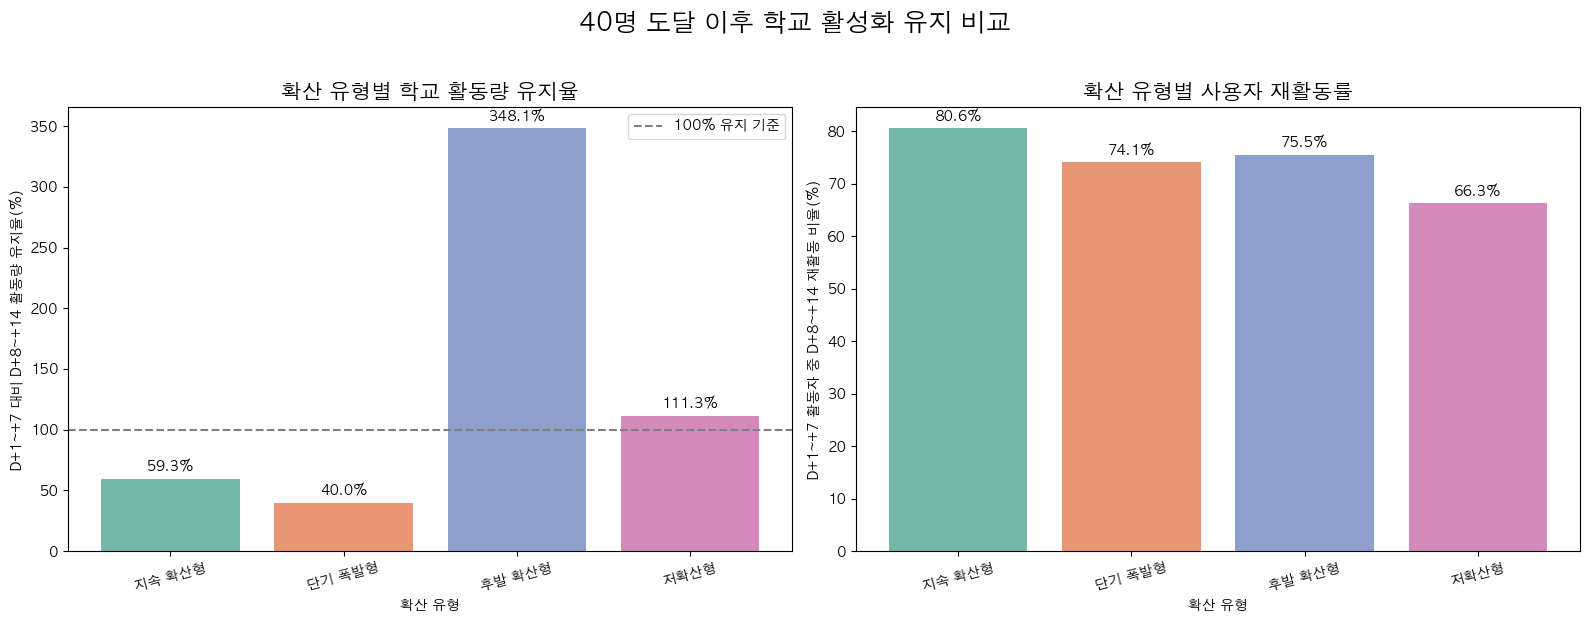

In [17]:
# ============================================================
# 15-6. 학교 활성화 유지 지표 시각화
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형",
]

colors = [
    "#72B7A8",
    "#E99675",
    "#8DA0CB",
    "#D58ABD",
]

# ------------------------------------------------------------
# 1. 시각화용 데이터 정리
# ------------------------------------------------------------

volume_plot = type_volume_retention.copy()
user_plot = type_user_retention.copy()

volume_plot["확산유형"] = volume_plot["확산유형"].astype(str)
user_plot["확산유형"] = user_plot["확산유형"].astype(str)

volume_plot["확산유형"] = pd.Categorical(
    volume_plot["확산유형"],
    categories=type_order,
    ordered=True
)

user_plot["확산유형"] = pd.Categorical(
    user_plot["확산유형"],
    categories=type_order,
    ordered=True
)

volume_plot = volume_plot.sort_values("확산유형")
user_plot = user_plot.sort_values("확산유형")


# ------------------------------------------------------------
# 2. 시각화
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# 학교 전체 활동량 유지율
bars1 = axes[0].bar(
    volume_plot["확산유형"],
    volume_plot["전체활동량유지율(%)"],
    color=colors
)

axes[0].axhline(
    100,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="100% 유지 기준"
)

axes[0].set_title(
    "확산 유형별 학교 활동량 유지율",
    fontsize=15
)

axes[0].set_xlabel("확산 유형")
axes[0].set_ylabel("D+1~+7 대비 D+8~+14 활동량 유지율(%)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

axes[0].bar_label(
    bars1,
    fmt="%.1f%%",
    padding=3
)


# 사용자 재활동률
bars2 = axes[1].bar(
    user_plot["확산유형"],
    user_plot["전체사용자재활동률(%)"],
    color=colors
)

axes[1].set_title(
    "확산 유형별 사용자 재활동률",
    fontsize=15
)

axes[1].set_xlabel("확산 유형")
axes[1].set_ylabel(
    "D+1~+7 활동자 중 D+8~+14 재활동 비율(%)"
)

axes[1].tick_params(axis="x", rotation=15)

axes[1].bar_label(
    bars2,
    fmt="%.1f%%",
    padding=3
)

# 공통 제목
fig.suptitle(
    "40명 도달 이후 학교 활성화 유지 비교",
    fontsize=18,
    y=1.03
)

plt.tight_layout()
plt.show()

# 실제 몇개 학교에서 1건 이상 관찰됐는지 40개 계정 도달 이후 과정 확인

In [18]:
# ============================================================
# 16-1. 기능별 데이터 커버리지 점검
# ============================================================

import pandas as pd
import numpy as np

week1_label = "도달 직후 D+1~+7"
week2_label = "도달 후기 D+8~+14"

type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형",
]

# ------------------------------------------------------------
# 1. 점검할 원본 기능 컬럼
# ------------------------------------------------------------

feature_columns = {
    "출석": "attendance_record_count",
    "질문 생성": "db_question_set_created_count",
    "투표 참여": "db_vote_record_created_count",
    "Ping 수신": "db_ping_received_record_count",
    "Ping 읽기": "ping_current_read_record_count",
    "Ping 답변": "ping_current_answered_record_count",
    "포인트 획득": "point_earn_event_count",
    "포인트 사용": "point_spend_event_count",
}

# 실제 데이터에 존재하는 기능만 선택
available_features = {
    feature_name: column_name
    for feature_name, column_name in feature_columns.items()
    if column_name in activity_analysis.columns
}

print("[커버리지 점검 대상 기능]")

for feature_name, column_name in available_features.items():
    print(f"- {feature_name}: {column_name}")


# ------------------------------------------------------------
# 2. D+1~+14 데이터만 선택
# ------------------------------------------------------------

coverage_source = activity_analysis.loc[
    activity_analysis["기간"].isin(
        [week1_label, week2_label]
    ),
    [
        "school_id",
        "확산유형",
        "기간",
    ] + list(available_features.values())
].copy()


# ------------------------------------------------------------
# 3. 학교·기간별 기능 활동량 집계
# ------------------------------------------------------------

school_feature_period = (
    coverage_source
    .groupby(
        ["school_id", "확산유형", "기간"],
        observed=True
    )[list(available_features.values())]
    .sum()
    .reset_index()
)


# ------------------------------------------------------------
# 4. 전체 학교 × 두 기간 기준표 생성
#    활동 기록이 없는 학교도 0으로 포함
# ------------------------------------------------------------

all_school_periods = (
    all_analysis_schools[
        ["school_id", "확산유형"]
    ]
    .drop_duplicates()
    .merge(
        pd.DataFrame(
            {"기간": [week1_label, week2_label]}
        ),
        how="cross"
    )
)

school_feature_period_full = all_school_periods.merge(
    school_feature_period,
    on=["school_id", "확산유형", "기간"],
    how="left"
)

feature_raw_columns = list(available_features.values())

school_feature_period_full[feature_raw_columns] = (
    school_feature_period_full[feature_raw_columns]
    .fillna(0)
)


# ------------------------------------------------------------
# 5. 기능별 커버리지 표 생성
# ------------------------------------------------------------

coverage_results = []

for feature_name, column_name in available_features.items():

    for diffusion_type in type_order:

        for period in [week1_label, week2_label]:

            subset = school_feature_period_full[
                (school_feature_period_full["확산유형"] == diffusion_type)
                & (school_feature_period_full["기간"] == period)
            ]

            total_schools = subset["school_id"].nunique()

            observed_schools = subset.loc[
                subset[column_name] > 0,
                "school_id"
            ].nunique()

            coverage_rate = (
                observed_schools / total_schools * 100
                if total_schools > 0
                else np.nan
            )

            coverage_results.append(
                {
                    "확산유형": diffusion_type,
                    "기간": period,
                    "기능": feature_name,
                    "전체학교수": total_schools,
                    "활동관찰학교수": observed_schools,
                    "활동관찰학교비율(%)": coverage_rate,
                    "총활동건수": subset[column_name].sum(),
                }
            )

feature_coverage = pd.DataFrame(coverage_results)

feature_coverage["활동관찰학교비율(%)"] = (
    feature_coverage["활동관찰학교비율(%)"].round(2)
)

feature_coverage["총활동건수"] = (
    feature_coverage["총활동건수"].round(0).astype("int64")
)


# ------------------------------------------------------------
# 6. 전체 학교 기준 기능별 커버리지 요약
# ------------------------------------------------------------

overall_coverage_results = []

for feature_name, column_name in available_features.items():

    for period in [week1_label, week2_label]:

        subset = school_feature_period_full[
            school_feature_period_full["기간"] == period
        ]

        total_schools = subset["school_id"].nunique()

        observed_schools = subset.loc[
            subset[column_name] > 0,
            "school_id"
        ].nunique()

        overall_coverage_results.append(
            {
                "기간": period,
                "기능": feature_name,
                "전체학교수": total_schools,
                "활동관찰학교수": observed_schools,
                "활동관찰학교비율(%)": (
                    observed_schools / total_schools * 100
                    if total_schools > 0
                    else np.nan
                ),
                "총활동건수": subset[column_name].sum(),
            }
        )

overall_feature_coverage = pd.DataFrame(
    overall_coverage_results
)

overall_feature_coverage["활동관찰학교비율(%)"] = (
    overall_feature_coverage[
        "활동관찰학교비율(%)"
    ].round(2)
)

overall_feature_coverage["총활동건수"] = (
    overall_feature_coverage["총활동건수"]
    .round(0)
    .astype("int64")
)


# ------------------------------------------------------------
# 7. 결과 출력
# ------------------------------------------------------------

print("\n[전체 학교 기준 기능별 커버리지]")
display(overall_feature_coverage)

print("\n[확산 유형별 기능 커버리지]")
display(feature_coverage)


# ------------------------------------------------------------
# 8. 비교하기 쉬운 피벗 테이블
# ------------------------------------------------------------

coverage_pivot = feature_coverage.pivot_table(
    index=["확산유형", "기능"],
    columns="기간",
    values="활동관찰학교비율(%)",
    observed=True
).reset_index()

coverage_pivot = coverage_pivot.rename(
    columns={
        week1_label: "D1_7_관찰학교비율(%)",
        week2_label: "D8_14_관찰학교비율(%)",
    }
)

print("\n[기능별·기간별 관찰 학교 비율]")
display(coverage_pivot)

[커버리지 점검 대상 기능]
- 출석: attendance_record_count
- 질문 생성: db_question_set_created_count
- 투표 참여: db_vote_record_created_count
- Ping 수신: db_ping_received_record_count
- Ping 읽기: ping_current_read_record_count
- Ping 답변: ping_current_answered_record_count
- 포인트 획득: point_earn_event_count
- 포인트 사용: point_spend_event_count

[전체 학교 기준 기능별 커버리지]


,기간,기능,전체학교수,활동관찰학교수,활동관찰학교비율(%),총활동건수
0,도달 직후 D+1~+7,출석,3795,806,21.24,107104
1,도달 후기 D+8~+14,출석,3795,1751,46.14,253304
2,도달 직후 D+1~+7,질문 생성,3795,10,0.26,84357
3,도달 후기 D+8~+14,질문 생성,3795,10,0.26,41792
4,도달 직후 D+1~+7,투표 참여,3795,10,0.26,644193
5,도달 후기 D+8~+14,투표 참여,3795,10,0.26,331870
6,도달 직후 D+1~+7,Ping 수신,3795,683,18.00,649030
7,도달 후기 D+8~+14,Ping 수신,3795,784,20.66,321869
8,도달 직후 D+1~+7,Ping 읽기,3795,606,15.97,374333
9,도달 후기 D+8~+14,Ping 읽기,3795,640,16.86,180698



[확산 유형별 기능 커버리지]


,확산유형,기간,기능,전체학교수,활동관찰학교수,활동관찰학교비율(%),총활동건수
0,지속 확산형,도달 직후 D+1~+7,출석,1382,70,5.07,9349
1,지속 확산형,도달 후기 D+8~+14,출석,1382,442,31.98,85868
2,단기 폭발형,도달 직후 D+1~+7,출석,540,144,26.67,26321
3,단기 폭발형,도달 후기 D+8~+14,출석,540,261,48.33,59201
4,후발 확산형,도달 직후 D+1~+7,출석,586,65,11.09,6809
...,...,...,...,...,...,...,...
59,단기 폭발형,도달 후기 D+8~+14,포인트 사용,540,1,0.19,549
60,후발 확산형,도달 직후 D+1~+7,포인트 사용,586,0,0.00,0
61,후발 확산형,도달 후기 D+8~+14,포인트 사용,586,0,0.00,0
62,저확산형,도달 직후 D+1~+7,포인트 사용,1287,0,0.00,0



[기능별·기간별 관찰 학교 비율]


기간,확산유형,기능,D1_7_관찰학교비율(%),D8_14_관찰학교비율(%)
0,단기 폭발형,Ping 답변,9.07,6.48
1,단기 폭발형,Ping 수신,20.00,19.26
2,단기 폭발형,Ping 읽기,17.96,15.00
3,단기 폭발형,질문 생성,0.19,0.19
4,단기 폭발형,출석,26.67,48.33
5,단기 폭발형,투표 참여,0.19,0.19
6,단기 폭발형,포인트 사용,0.19,0.19
7,단기 폭발형,포인트 획득,0.19,0.19
8,저확산형,Ping 답변,5.91,3.96
9,저확산형,Ping 수신,12.90,11.89


In [19]:
# ============================================================
# 16-2. 출석·Ping 기능별 유지율 계산
# ============================================================

import pandas as pd
import numpy as np

week1_label = "도달 직후 D+1~+7"
week2_label = "도달 후기 D+8~+14"

type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형",
]

# 실제 사용자 행동에 해당하는 기능만 사용
retention_features = {
    "출석": "attendance_record_count",
    "Ping 읽기": "ping_current_read_record_count",
    "Ping 답변": "ping_current_answered_record_count",
}

feature_retention_results = []

for diffusion_type in type_order:
    for feature_name, column_name in retention_features.items():

        type_data = school_feature_period_full[
            school_feature_period_full["확산유형"]
            == diffusion_type
        ]

        week1_data = type_data[
            type_data["기간"] == week1_label
        ]

        week2_data = type_data[
            type_data["기간"] == week2_label
        ]

        total_schools = type_data["school_id"].nunique()

        if total_schools == 0:
            continue

        week1_volume = week1_data[column_name].sum()
        week2_volume = week2_data[column_name].sum()

        week1_active_schools = (
            week1_data.loc[
                week1_data[column_name] > 0,
                "school_id"
            ].nunique()
        )

        week2_active_schools = (
            week2_data.loc[
                week2_data[column_name] > 0,
                "school_id"
            ].nunique()
        )

        volume_retention = (
            week2_volume / week1_volume * 100
            if week1_volume > 0
            else np.nan
        )

        feature_retention_results.append(
            {
                "확산유형": diffusion_type,
                "기능": feature_name,
                "전체학교수": total_schools,
                "D1_7_활동학교수": week1_active_schools,
                "D8_14_활동학교수": week2_active_schools,
                "D1_7_활동학교비율(%)": (
                    week1_active_schools
                    / total_schools
                    * 100
                ),
                "D8_14_활동학교비율(%)": (
                    week2_active_schools
                    / total_schools
                    * 100
                ),
                "D1_7_총활동량": week1_volume,
                "D8_14_총활동량": week2_volume,
                "기능활동량유지율(%)": volume_retention,
            }
        )

feature_retention_summary = pd.DataFrame(
    feature_retention_results
)

percentage_columns = [
    "D1_7_활동학교비율(%)",
    "D8_14_활동학교비율(%)",
    "기능활동량유지율(%)",
]

feature_retention_summary[percentage_columns] = (
    feature_retention_summary[percentage_columns].round(2)
)

print("[출석·Ping 기능별 유지율]")
display(feature_retention_summary)

[출석·Ping 기능별 유지율]


,확산유형,기능,전체학교수,D1_7_활동학교수,D8_14_활동학교수,D1_7_활동학교비율(%),D8_14_활동학교비율(%),D1_7_총활동량,D8_14_총활동량,기능활동량유지율(%)
0,지속 확산형,출석,1382,70,442,5.07,31.98,9349,85868,918.47
1,지속 확산형,Ping 읽기,1382,295,345,21.35,24.96,332835,172616,51.86
2,지속 확산형,Ping 답변,1382,180,193,13.02,13.97,63120,33570,53.18
3,단기 폭발형,출석,540,144,261,26.67,48.33,26321,59201,224.92
4,단기 폭발형,Ping 읽기,540,97,81,17.96,15.00,33017,5144,15.58
5,단기 폭발형,Ping 답변,540,49,35,9.07,6.48,5338,772,14.46
6,후발 확산형,출석,586,65,278,11.09,47.44,6809,29839,438.23
7,후발 확산형,Ping 읽기,586,74,96,12.63,16.38,1847,1310,70.93
8,후발 확산형,Ping 답변,586,39,41,6.66,7.00,355,217,61.13
9,저확산형,출석,1287,527,770,40.95,59.83,64625,78396,121.31


In [20]:
# ============================================================
# 16-3. 출석·Ping 기준 사용자 재활동률 재계산
# ============================================================

core_action_columns = [
    "attendance_record_count",
    "ping_current_read_record_count",
    "ping_current_answered_record_count",
]

# ------------------------------------------------------------
# 1. 필요한 기간과 컬럼만 선택
# ------------------------------------------------------------

core_activity_source = activity_analysis.loc[
    activity_analysis["기간"].isin(
        [week1_label, week2_label]
    ),
    [
        "school_id",
        "확산유형",
        "user_id",
        "기간",
    ] + core_action_columns
].copy()

# 출석·Ping 읽기·Ping 답변 중 하나라도 수행했는지
core_activity_source["핵심활동여부"] = (
    core_activity_source[core_action_columns]
    .sum(axis=1)
    > 0
).astype(int)


# ------------------------------------------------------------
# 2. 첫째 주 활동 사용자
# ------------------------------------------------------------

core_week1_users = (
    core_activity_source.loc[
        (core_activity_source["기간"] == week1_label)
        & (core_activity_source["핵심활동여부"] == 1),
        ["school_id", "확산유형", "user_id"]
    ]
    .drop_duplicates()
)

# ------------------------------------------------------------
# 3. 둘째 주 활동 사용자
# ------------------------------------------------------------

core_week2_users = (
    core_activity_source.loc[
        (core_activity_source["기간"] == week2_label)
        & (core_activity_source["핵심활동여부"] == 1),
        ["school_id", "user_id"]
    ]
    .drop_duplicates()
)

print(
    "D+1~+7 출석·Ping 활동 사용자:",
    f"{len(core_week1_users):,}명"
)

print(
    "D+8~+14 출석·Ping 활동 사용자:",
    f"{len(core_week2_users):,}명"
)


# ------------------------------------------------------------
# 4. 동일 사용자의 둘째 주 재활동 확인
# ------------------------------------------------------------

core_reactivated_users = core_week1_users.merge(
    core_week2_users.assign(재활동여부=1),
    on=["school_id", "user_id"],
    how="left",
    validate="one_to_one"
)

core_reactivated_users["재활동여부"] = (
    core_reactivated_users["재활동여부"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 5. 확산 유형별 사용자 재활동률
# ------------------------------------------------------------

core_user_retention_summary = (
    core_reactivated_users
    .groupby("확산유형", observed=True)
    .agg(
        D1_7_활동사용자수=("user_id", "nunique"),
        두기간모두활동사용자수=("재활동여부", "sum"),
    )
    .reset_index()
)

week2_type_users = (
    core_week2_users
    .merge(
        all_analysis_schools[
            ["school_id", "확산유형"]
        ].drop_duplicates(),
        on="school_id",
        how="left",
        validate="many_to_one"
    )
    .groupby("확산유형", observed=True)
    ["user_id"]
    .nunique()
    .reset_index(name="D8_14_활동사용자수")
)

core_user_retention_summary = (
    core_user_retention_summary.merge(
        week2_type_users,
        on="확산유형",
        how="outer"
    )
)

core_user_retention_summary[
    [
        "D1_7_활동사용자수",
        "D8_14_활동사용자수",
        "두기간모두활동사용자수",
    ]
] = core_user_retention_summary[
    [
        "D1_7_활동사용자수",
        "D8_14_활동사용자수",
        "두기간모두활동사용자수",
    ]
].fillna(0).astype(int)

core_user_retention_summary[
    "출석Ping_사용자재활동률(%)"
] = np.where(
    core_user_retention_summary[
        "D1_7_활동사용자수"
    ] > 0,
    (
        core_user_retention_summary[
            "두기간모두활동사용자수"
        ]
        / core_user_retention_summary[
            "D1_7_활동사용자수"
        ]
        * 100
    ),
    np.nan
)

core_user_retention_summary[
    "출석Ping_사용자재활동률(%)"
] = core_user_retention_summary[
    "출석Ping_사용자재활동률(%)"
].round(2)

core_user_retention_summary["확산유형"] = pd.Categorical(
    core_user_retention_summary["확산유형"],
    categories=type_order,
    ordered=True
)

core_user_retention_summary = (
    core_user_retention_summary
    .sort_values("확산유형")
    .reset_index(drop=True)
)

print("\n[출석·Ping 기준 사용자 재활동률]")
display(core_user_retention_summary)

# 메모리 정리
del core_activity_source
del core_week1_users
del core_week2_users
del core_reactivated_users

D+1~+7 출석·Ping 활동 사용자: 53,025명
D+8~+14 출석·Ping 활동 사용자: 101,070명

[출석·Ping 기준 사용자 재활동률]


,확산유형,D1_7_활동사용자수,두기간모두활동사용자수,D8_14_활동사용자수,출석Ping_사용자재활동률(%)
0,지속 확산형,12645,9957,42350,78.74
1,단기 폭발형,13500,9906,20809,73.38
2,후발 확산형,3123,2359,12186,75.54
3,저확산형,23757,15751,25725,66.30


# 기능별 유지율과 출석·Ping 기준 사용자 재활동률을 시각화

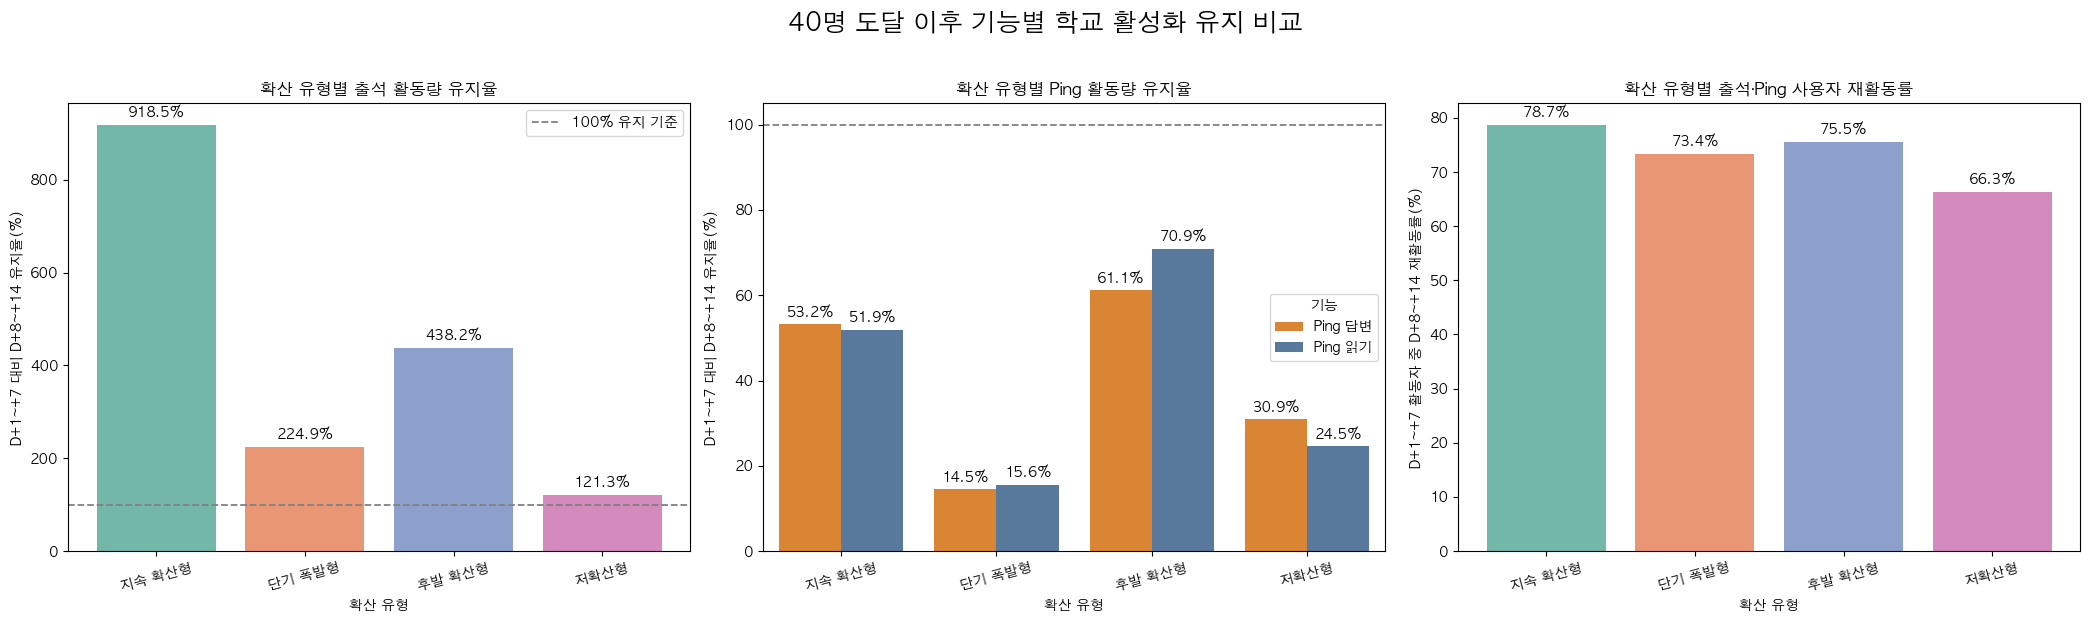

In [21]:
# ============================================================
# 16-4. 출석·Ping 기능별 유지율 및 사용자 재활동률 시각화
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형",
]

colors = {
    "지속 확산형": "#72B7A8",
    "단기 폭발형": "#E99675",
    "후발 확산형": "#8DA0CB",
    "저확산형": "#D58ABD",
}

# ------------------------------------------------------------
# 1. 시각화 데이터 정리
# ------------------------------------------------------------

feature_plot = feature_retention_summary.copy()
user_plot = core_user_retention_summary.copy()

feature_plot["확산유형"] = feature_plot["확산유형"].astype(str)
user_plot["확산유형"] = user_plot["확산유형"].astype(str)

feature_plot["확산유형"] = pd.Categorical(
    feature_plot["확산유형"],
    categories=type_order,
    ordered=True
)

user_plot["확산유형"] = pd.Categorical(
    user_plot["확산유형"],
    categories=type_order,
    ordered=True
)

attendance_plot = (
    feature_plot[
        feature_plot["기능"] == "출석"
    ]
    .sort_values("확산유형")
)

ping_plot = (
    feature_plot[
        feature_plot["기능"].isin(
            ["Ping 읽기", "Ping 답변"]
        )
    ]
    .sort_values(["확산유형", "기능"])
)

user_plot = user_plot.sort_values("확산유형")


# ------------------------------------------------------------
# 2. 그래프 생성
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)

# ------------------------------------------------------------
# 그래프 1: 출석 활동량 유지율
# ------------------------------------------------------------

bars1 = axes[0].bar(
    attendance_plot["확산유형"],
    attendance_plot["기능활동량유지율(%)"],
    color=[
        colors[str(x)]
        for x in attendance_plot["확산유형"]
    ]
)

axes[0].axhline(
    100,
    color="gray",
    linestyle="--",
    linewidth=1.3,
    label="100% 유지 기준"
)

axes[0].set_title("확산 유형별 출석 활동량 유지율")
axes[0].set_xlabel("확산 유형")
axes[0].set_ylabel("D+1~+7 대비 D+8~+14 유지율(%)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

axes[0].bar_label(
    bars1,
    fmt="%.1f%%",
    padding=3
)


# ------------------------------------------------------------
# 그래프 2: Ping 읽기·답변 유지율
# ------------------------------------------------------------

sns.barplot(
    data=ping_plot,
    x="확산유형",
    y="기능활동량유지율(%)",
    hue="기능",
    ax=axes[1],
    palette={
        "Ping 읽기": "#4C78A8",
        "Ping 답변": "#F58518",
    }
)

axes[1].axhline(
    100,
    color="gray",
    linestyle="--",
    linewidth=1.3
)

axes[1].set_title("확산 유형별 Ping 활동량 유지율")
axes[1].set_xlabel("확산 유형")
axes[1].set_ylabel("D+1~+7 대비 D+8~+14 유지율(%)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="기능")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# ------------------------------------------------------------
# 그래프 3: 출석·Ping 사용자 재활동률
# ------------------------------------------------------------

bars3 = axes[2].bar(
    user_plot["확산유형"],
    user_plot["출석Ping_사용자재활동률(%)"],
    color=[
        colors[str(x)]
        for x in user_plot["확산유형"]
    ]
)

axes[2].set_title("확산 유형별 출석·Ping 사용자 재활동률")
axes[2].set_xlabel("확산 유형")
axes[2].set_ylabel(
    "D+1~+7 활동자 중 D+8~+14 재활동률(%)"
)
axes[2].tick_params(axis="x", rotation=15)

axes[2].bar_label(
    bars3,
    fmt="%.1f%%",
    padding=3
)

fig.suptitle(
    "40명 도달 이후 기능별 학교 활성화 유지 비교",
    fontsize=18,
    y=1.03
)

plt.tight_layout()
plt.show()

## 출석 기록만 사용한 사용자 재활동률

In [22]:
# 현재 상태 Ping 지표를 제외한 출석 기록 기준 비교
attendance_source = activity_analysis.loc[
    activity_analysis["attendance_record_count"].gt(0),
    ["school_id", "user_id", "확산유형", "기간"]
].drop_duplicates()
a1 = attendance_source[attendance_source["기간"].eq(week1_label)][
    ["school_id", "user_id", "확산유형"]].drop_duplicates()
a2 = attendance_source[attendance_source["기간"].eq(week2_label)][
    ["school_id", "user_id"]].drop_duplicates()
attendance_cohort = a1.merge(a2.assign(returned=1), on=["school_id", "user_id"],
                             how="left", validate="one_to_one")
attendance_cohort["returned"] = attendance_cohort["returned"].fillna(0)
attendance_retention = attendance_cohort.groupby("확산유형", observed=True).agg(
    첫째주출석사용자수=("user_id", "nunique"), 두기간출석사용자수=("returned", "sum")
).reset_index()
attendance_retention["출석기준재활동률(%)"] = (
    attendance_retention["두기간출석사용자수"] / attendance_retention["첫째주출석사용자수"] * 100
).round(2)
display(attendance_retention)
print("출석 기록 기준입니다. 앱 전체 방문 리텐션과 구분하세요.")

,확산유형,첫째주출석사용자수,두기간출석사용자수,출석기준재활동률(%)
0,단기 폭발형,12416,"9,244.00",74.45
1,저확산형,23148,"15,447.00",66.73
2,지속 확산형,5350,"4,526.00",84.60
3,후발 확산형,2872,"2,231.00",77.68


출석 기록 기준입니다. 앱 전체 방문 리텐션과 구분하세요.
